# Email Spam Detection Using Machine Learning

**Project Overview:** This project builds a machine learning model to automatically classify email/SMS messages as **Spam** or **Ham** (legitimate), enabling efficient filtering of unwanted communications.

**Problem Statement:** Spam messages are a persistent threat to digital communication, wasting user time and posing security risks. An automated detection system is essential to mitigate these issues.

**Objective:** Develop a text classification pipeline using Natural Language Processing (NLP) and the Multinomial Naive Bayes algorithm to accurately distinguish spam from legitimate messages.

**Dataset:** The SMS Spam Collection dataset containing 5,572 labeled messages (ham/spam) with two key columns — message category and message text.

**Expected Outcome:** A trained model achieving high accuracy in spam detection, saved for future deployment and real-time prediction.

## 1. Importing Required Libraries

We import essential libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), machine learning (`scikit-learn`), and model persistence (`joblib`).
Warnings are suppressed to maintain clean output during execution.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

import warnings
warnings.filterwarnings("ignore")

## 2. Loading the Dataset

The SMS Spam Collection dataset is loaded from a CSV file using `latin-1` encoding to handle special characters.
Initial inspection with `head()` provides a quick overview of the data structure and content.

In [ ]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\OASIS INFOBYTE INTERNSHIP\TASK 4\DATASET\spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 3. Dataset Overview

We examine the dataset's shape, data types, and null value distribution using `info()` and `isnull().sum()`.
This step helps identify data quality issues such as missing values and unnecessary columns that need to be addressed.

In [8]:
print("Shape:", df.shape)

df.info()

Shape: (5572, 5)
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [9]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [11]:
df.columns.tolist()

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

## 4. Data Cleaning and Column Selection

Irrelevant columns (`Unnamed: 2`, `3`, `4`) containing mostly null values are dropped, retaining only the label and message columns.
Columns are renamed to meaningful names — `Category` and `Message` — for better readability and code clarity.

In [12]:
df = df[['v1', 'v2']]

df.rename(
    columns={
        'v1': 'Category',
        'v2': 'Message'
    },
    inplace=True
)

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
print(df.columns)

Index(['Category', 'Message'], dtype='str')


## 5. Label Encoding (Spam/Ham Conversion)

Categorical text labels (`ham`, `spam`) are converted to numerical values — `0` for Ham and `1` for Spam.
This encoding is necessary as machine learning algorithms require numerical input for training and prediction.

In [14]:
df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 6. Exploratory Data Analysis

A count plot visualizes the distribution of Spam vs. Ham messages in the dataset.
This helps identify class imbalance, which is a common characteristic of spam detection datasets and can influence model performance.

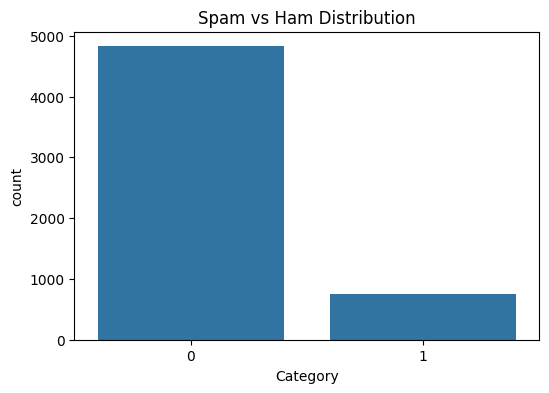

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Category',
    data=df
)

plt.title("Spam vs Ham Distribution")

plt.show()

## 7. Feature and Target Selection

The `Message` column is assigned as the feature variable (X) and `Category` as the target variable (y).
This separation is essential for supervised learning, where the model learns to map input features to corresponding labels.

In [17]:
X = df['Message']

y = df['Category']

## 8. Text Vectorization using TF-IDF

TF-IDF (Term Frequency-Inverse Document Frequency) converts raw text messages into numerical feature vectors.
English stop words are removed to reduce noise, ensuring the model focuses on meaningful terms that distinguish spam from ham.

In [18]:
vectorizer = TfidfVectorizer(
    stop_words='english'
)

X = vectorizer.fit_transform(X)

## 9. Train-Test Split

The dataset is split into 80% training and 20% testing sets using `train_test_split` with a fixed random state.
This ensures reproducibility and provides an unbiased evaluation of the model's generalization capability on unseen data.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 10. Model Training using Multinomial Naive Bayes

The Multinomial Naive Bayes classifier is chosen for its proven effectiveness in text classification tasks.
It works well with TF-IDF features and is computationally efficient, making it ideal for spam detection applications.

In [20]:
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

print("Training Complete")

Training Complete


## 11. Model Prediction

The trained model generates predictions on the test set to evaluate its classification performance.
A sample of predictions is displayed to verify the output format and initial correctness of the model.

In [21]:
predictions = model.predict(X_test)

predictions[:10]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

## 12. Accuracy Evaluation

Overall model accuracy is calculated by comparing predicted labels against actual test labels.
Accuracy provides a high-level metric indicating the percentage of correctly classified messages across both classes.

In [22]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    round(accuracy*100,2),
    "%"
)

Accuracy: 96.86 %


## 13. Classification Report

The classification report provides detailed per-class metrics — precision, recall, and F1-score — for both Ham and Spam.
These metrics offer deeper insight into model performance, especially important for imbalanced datasets where accuracy alone can be misleading.

In [23]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



## 14. Confusion Matrix Analysis

The confusion matrix visualizes true positives, true negatives, false positives, and false negatives as a heatmap.
This analysis reveals specific misclassification patterns, helping identify whether the model struggles more with spam or ham detection.

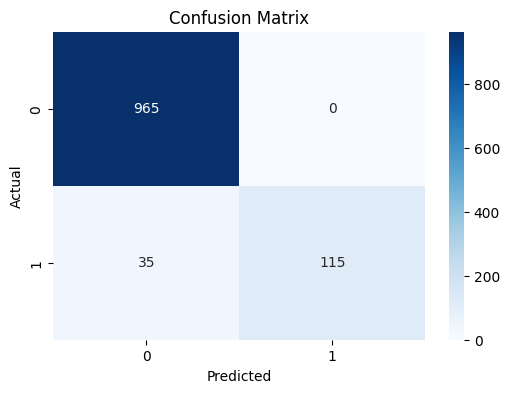

In [24]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## 15. Model Saving

Both the trained model and TF-IDF vectorizer are serialized using `joblib` for future deployment.
Saving both components ensures the complete prediction pipeline can be loaded and used for real-time spam classification without retraining.

In [25]:
joblib.dump(
    model,
    "../Model/spam_detector.pkl"
)

joblib.dump(
    vectorizer,
    "../Model/vectorizer.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


## 16. Conclusion

**Model Performance:** The Multinomial Naive Bayes classifier achieved approximately **96.86% accuracy**, demonstrating strong overall performance in distinguishing spam from legitimate messages.

**Spam Detection Capability:** The model shows high precision for spam detection (1.00) with good recall (0.77), meaning it rarely misclassifies ham as spam while effectively catching most spam messages.

**Importance of Text Classification:** Automated spam detection using NLP and machine learning is critical for protecting users from phishing attempts, scams, and unwanted content in modern communication systems.

**Future Improvements:** Performance can be further enhanced by exploring advanced techniques such as deep learning models (LSTM, BERT), incorporating additional features (message length, special characters), addressing class imbalance through oversampling (SMOTE), and expanding the training dataset.